# Clustering team-seasons by batting profile

Grouping all 1,232 team-seasons purely by their offensive profile (OBP,
SLG, runs scored, runs allowed), no wins or playoff information
involved, then checking whether the clusters found line up with actual
team success.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseball = pd.read_pickle('data/baseball_clean.pkl')
feature_cols = ['OBP', 'SLG', 'RS', 'RA']
X = baseball[feature_cols]
X.shape

(1232, 4)

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components = 2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)
print(f'2 components explain {pca.explained_variance_ratio_.sum():.1%} of variance')

2 components explain 93.8% of variance


In [3]:
K = 4
kmeans = KMeans(n_clusters = K, n_init = 10, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components = K, random_state = 42, n_init = 3)
gmm_labels = gmm.fit_predict(X_scaled)

print('KMeans silhouette:', silhouette_score(X_scaled, kmeans_labels))
print('KMeans vs GMM agreement (ARI):', adjusted_rand_score(kmeans_labels, gmm_labels))

KMeans silhouette: 0.2940019841671664
KMeans vs GMM agreement (ARI): 0.6135992281831387


In [4]:
profile = baseball.assign(cluster = kmeans_labels)
cluster_summary = profile.groupby('cluster').agg(
    n = ('W', 'size'),
    mean_wins = ('W', 'mean'),
    playoff_rate = ('Playoffs', 'mean'),
    mean_obp = ('OBP', 'mean'),
    mean_slg = ('SLG', 'mean'),
).round(3)
cluster_summary

,n,mean_wins,playoff_rate,mean_obp,mean_slg
cluster,,,,,
0,280,70.425,0.004,0.324,0.397
1,296,87.395,0.375,0.344,0.439
2,375,87.955,0.331,0.328,0.395
3,281,75.100,0.028,0.308,0.356


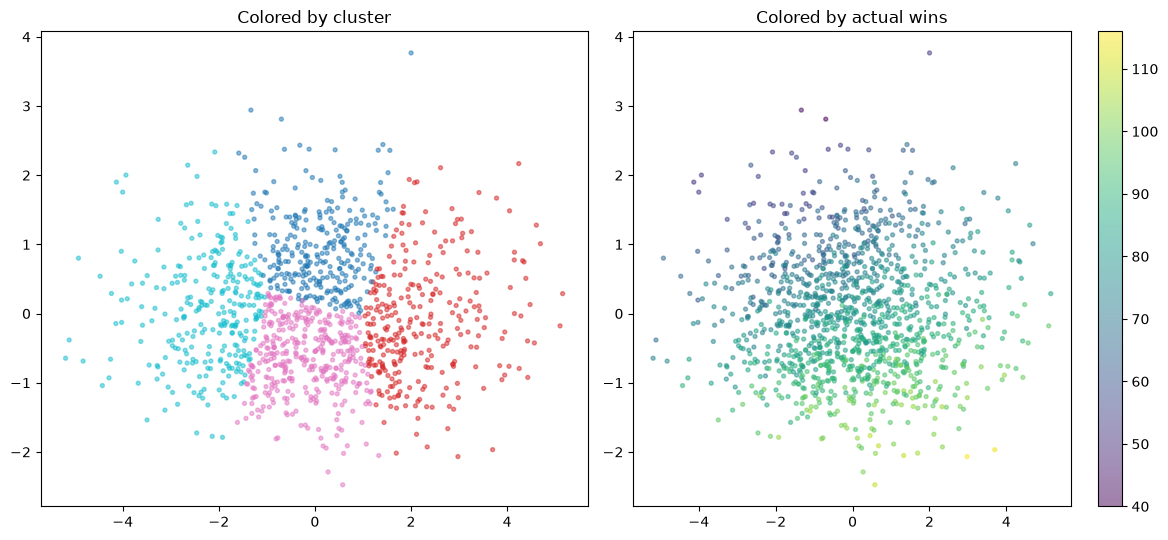

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5.5))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_labels, cmap = 'tab10', s = 8, alpha = 0.5)
axes[0].set_title('Colored by cluster')
sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c = baseball.W, cmap = 'viridis', s = 8, alpha = 0.5)
axes[1].set_title('Colored by actual wins')
plt.colorbar(sc1, ax = axes[1])
plt.tight_layout()
plt.savefig('outputs/cluster_pca.png', dpi = 120)
plt.show()

In [6]:
import json, os
os.makedirs('outputs', exist_ok = True)
with open('outputs/clustering_results.json', 'w') as f:
    json.dump({
        'k': K,
        'kmeans_silhouette': float(silhouette_score(X_scaled, kmeans_labels)),
        'kmeans_gmm_ari': float(adjusted_rand_score(kmeans_labels, gmm_labels)),
        'cluster_mean_wins': cluster_summary['mean_wins'].to_dict(),
        'cluster_playoff_rate': cluster_summary['playoff_rate'].to_dict(),
    }, f, indent = 2)

KMeans and the Gaussian mixture agree reasonably well here (ARI 0.61,
much stronger agreement than several other repos in this portfolio),
and the 4 clusters found from offensive profile alone, no wins or
playoff data involved, split cleanly into what are recognizably good
and bad team-seasons. Playoff rate ranges from 0.4% in the weakest
cluster to 37.5% in the strongest, and mean wins ranges from about 70
to 88, a real, substantial spread recovered entirely from OBP, SLG,
and the runs each team scored and allowed.